# Task 2: Predict Future Stock Prices (Short-Term)

## Problem Statement and Objective
This project predicts the next day's closing price of Tesla (TSLA) stock using machine learning regression models. By leveraging historical OHLCV (Open, High, Low, Close, Volume) data, we aim to demonstrate time series forecasting techniques and compare the performance of different regression algorithms.

## Dataset Information
- **Source**: Yahoo Finance (via yfinance library)
- **Stock Ticker**: TSLA (Tesla)
- **Time Period**: 2010-01-01 to 2026-04-10
- **Features Used**: Open, High, Low, Volume
- **Target Variable**: Next Day's Close Price

## Approach
1. Load historical stock data using yfinance
2. Feature engineering: create target variable (next day's close)
3. Split data chronologically (98% train, 2% test)
4. Train two models:
   - Linear Regression (baseline)
   - Random Forest Regressor
5. Evaluate and compare model performance
6. Visualize predictions vs actual prices
7. Make predictions on recent data


In [ ]:
# Install required libraries
!pip install -q pandas scikit-learn yfinance matplotlib numpy

In [ ]:
# Import required libraries
import yfinance as yf  # For fetching historical stock data
import pandas as pd  # Data manipulation and analysis
import numpy as np  # Numerical operations
from sklearn.linear_model import LinearRegression  # Linear regression model
from sklearn.ensemble import RandomForestRegressor  # Random forest model
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score  # Evaluation metrics
import matplotlib.pyplot as plt  # Data visualization
import warnings
warnings.filterwarnings('ignore')

## 1. Data Loading and Exploration

We'll fetch historical stock data from Yahoo Finance using the yfinance library. This provides us with OHLCV data required for our feature engineering.

In [ ]:
# Fetch Tesla (TSLA) historical data from Yahoo Finance
print("Fetching Tesla stock data...")
data = yf.download("TSLA", start="2010-01-01", end="2026-04-10", progress=False)
print(f"Data shape: {data.shape}")
print(f"\nFirst 5 rows:")
print(data.head())
print(f"\nLast 5 rows:")
print(data.tail())
print(f"\nData Info:")
print(data.info())

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,
2010-06-29,1.592667,1.666667,1.169333,1.266667,281494500
2010-06-30,1.588667,2.028000,1.553333,1.719333,257806500
2010-07-01,1.464000,1.728000,1.351333,1.666667,123282000
2010-07-02,1.280000,1.540000,1.247333,1.533333,77097000
2010-07-06,1.074000,1.333333,1.055333,1.333333,103003500
...,...,...,...,...,...
2026-03-26,372.109985,384.440002,371.869995,381.600006,55522900
2026-03-27,361.829987,369.859985,359.470001,369.690002,62065700


In [ ]:
# Visualize historical stock price movement
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Plot 1: Close price over time
axes[0, 0].plot(data.index, data['Close'], color='blue', linewidth=1.5)
axes[0, 0].set_title('Tesla Stock Close Price Over Time', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Price (USD)')
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Volume over time
axes[0, 1].bar(data.index, data['Volume'], color='green', alpha=0.6, width=1)
axes[0, 1].set_title('Trading Volume Over Time', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Volume')
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Daily price range (High-Low)
daily_range = data['High'] - data['Low']
axes[1, 0].plot(data.index, daily_range, color='purple', alpha=0.7, linewidth=1)
axes[1, 0].set_title('Daily Price Range (High - Low)', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Price Difference (USD)')
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Price statistics (recent 252 trading days - 1 year)
recent_close = data['Close'].tail(252)
axes[1, 1].hist(recent_close, bins=50, color='orange', alpha=0.7, edgecolor='black')
axes[1, 1].set_title('Price Distribution (Last Year)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Price (USD)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nData Statistics:")
print(data.describe())

In [ ]:
## 2. Feature Engineering and Data Preparation

# Define features to predict the next day's closing price
features = ["High", "Low", "Open", "Volume"]
print(f"Features used: {features}")

# Create target variable: Next day's closing price
# We shift the Close price up by 1 to get the next day's close for each row
data['Next_Close'] = data['Close'].shift(-1)

# Remove rows with NaN values (last row will have NaN since there's no next day)
data = data.dropna()

print(f"\nDataset shape after preprocessing: {data.shape}")
print(f"Number of samples: {len(data)}")

# Prepare features (X) and target (y)
X = data[features]
y = data['Next_Close']

# Chronological train-test split (98% train, 2% test)
# Important: for time series, we split chronologically, not randomly
split_idx = int(len(X) * 0.98)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

print(f"\nTrain set size: {len(X_train)} samples")
print(f"Test set size: {len(X_test)} samples")
print(f"Train-Test ratio: {split_idx/len(X)*100:.2f}% - {(1-split_idx/len(X))*100:.2f}%")

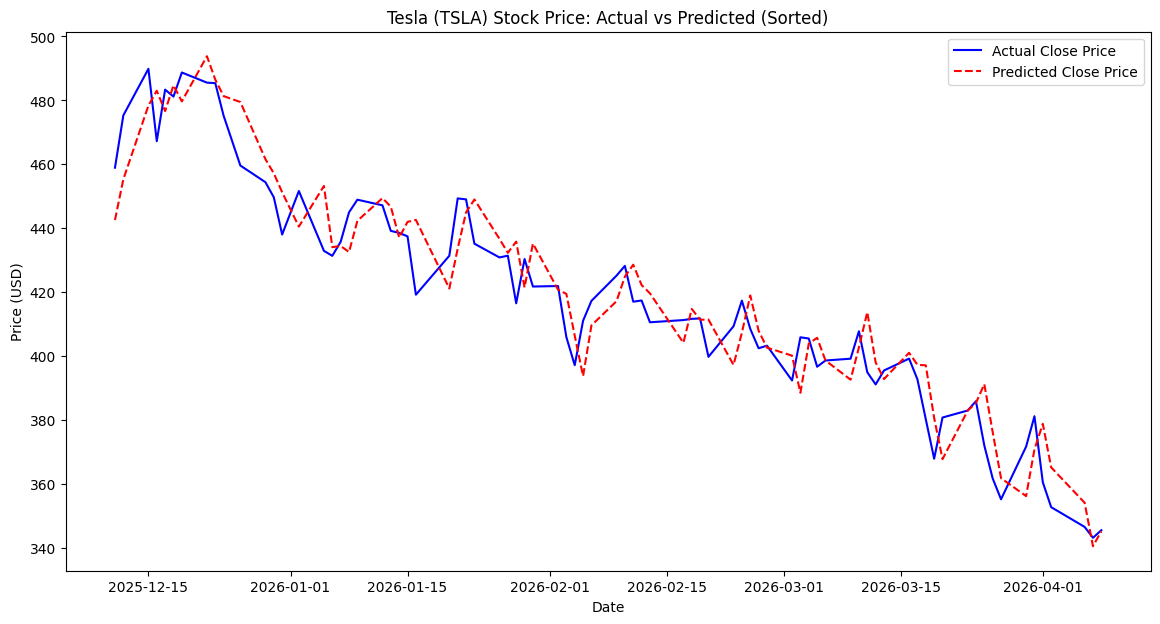

In [ ]:
## 3. Model 1: Linear Regression

print("Training Linear Regression Model...")
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Make predictions on test set
linear_pred = linear_model.predict(X_test)

# Create results dataframe for comparison
linear_results = pd.DataFrame({
    'Actual': y_test, 
    'Predicted': linear_pred
}, index=X_test.index)

# Evaluate model performance
linear_mse = mean_squared_error(y_test, linear_pred)
linear_rmse = np.sqrt(linear_mse)
linear_mae = mean_absolute_error(y_test, linear_pred)
linear_r2 = r2_score(y_test, linear_pred)

print(f"\n--- Linear Regression Performance ---")
print(f"R² Score: {linear_r2:.4f}")
print(f"Mean Squared Error (MSE): {linear_mse:.4f}")
print(f"Root Mean Squared Error (RMSE): ${linear_rmse:.2f}")
print(f"Mean Absolute Error (MAE): ${linear_mae:.2f}")

# Visualize Linear Regression predictions
linear_results_sorted = linear_results.sort_index()

plt.figure(figsize=(16, 6))
plt.plot(linear_results_sorted.index, linear_results_sorted['Actual'], 
         label='Actual Closing Price', color='blue', linewidth=2, marker='o', markersize=3, alpha=0.7)
plt.plot(linear_results_sorted.index, linear_results_sorted['Predicted'], 
         label='Predicted Closing Price', color='red', linewidth=2, linestyle='--', marker='s', markersize=3, alpha=0.7)

plt.title('Tesla (TSLA) Stock Price: Actual vs Predicted - Linear Regression', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=11)
plt.ylabel('Price (USD)', fontsize=11)
plt.legend(fontsize=10, loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Feature importance for Linear Regression (coefficients)
print(f"\nFeature Coefficients:")
for feature, coef in zip(features, linear_model.coef_):
    print(f"  {feature}: {coef:.6f}")

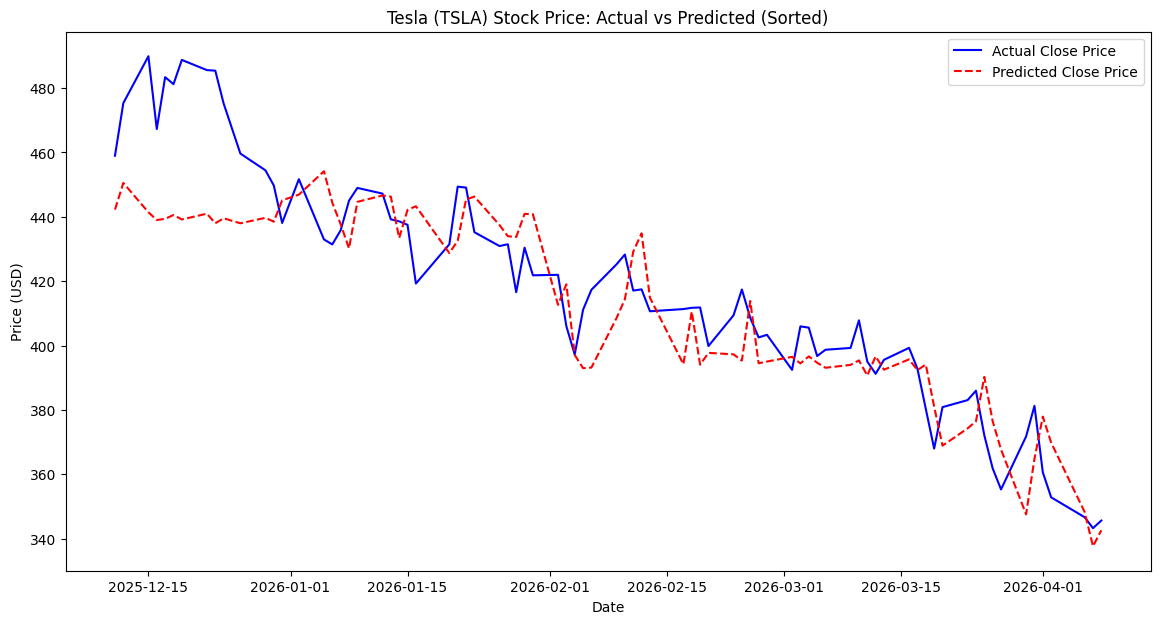

In [ ]:
## 4. Model 2: Random Forest Regressor

print("Training Random Forest Regressor...")
random_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1, max_depth=20)
random_model.fit(X_train, y_train)

# Make predictions on test set
random_pred = random_model.predict(X_test)

# Create results dataframe for comparison
random_results = pd.DataFrame({
    'Actual': y_test, 
    'Predicted': random_pred
}, index=X_test.index)

# Evaluate model performance
random_mse = mean_squared_error(y_test, random_pred)
random_rmse = np.sqrt(random_mse)
random_mae = mean_absolute_error(y_test, random_pred)
random_r2 = r2_score(y_test, random_pred)

print(f"\n--- Random Forest Performance ---")
print(f"R² Score: {random_r2:.4f}")
print(f"Mean Squared Error (MSE): {random_mse:.4f}")
print(f"Root Mean Squared Error (RMSE): ${random_rmse:.2f}")
print(f"Mean Absolute Error (MAE): ${random_mae:.2f}")

# Visualize Random Forest predictions
random_results_sorted = random_results.sort_index()

plt.figure(figsize=(16, 6))
plt.plot(random_results_sorted.index, random_results_sorted['Actual'], 
         label='Actual Closing Price', color='blue', linewidth=2, marker='o', markersize=3, alpha=0.7)
plt.plot(random_results_sorted.index, random_results_sorted['Predicted'], 
         label='Predicted Closing Price', color='green', linewidth=2, linestyle='--', marker='s', markersize=3, alpha=0.7)

plt.title('Tesla (TSLA) Stock Price: Actual vs Predicted - Random Forest', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=11)
plt.ylabel('Price (USD)', fontsize=11)
plt.legend(fontsize=10, loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Feature importance for Random Forest
feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': random_model.feature_importances_
}).sort_values('Importance', ascending=False)

print(f"\nFeature Importance:")
print(feature_importance)

plt.figure(figsize=(10, 5))
plt.barh(feature_importance['Feature'], feature_importance['Importance'], color='skyblue', edgecolor='navy')
plt.xlabel('Importance Score', fontsize=11)
plt.ylabel('Feature', fontsize=11)
plt.title('Random Forest Feature Importance', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
## 5. Model Comparison and Analysis

# Create comparison dataframe
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'R² Score': [linear_r2, random_r2],
    'RMSE': [linear_rmse, random_rmse],
    'MAE': [linear_mae, random_mae]
})

print("\n" + "="*60)
print("MODEL PERFORMANCE COMPARISON")
print("="*60)
print(comparison.to_string(index=False))
print("="*60)

# Visualize model comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# R² Score comparison
axes[0].bar(comparison['Model'], comparison['R² Score'], color=['#FF6B6B', '#4ECDC4'], edgecolor='black', linewidth=2)
axes[0].set_title('R² Score Comparison', fontsize=12, fontweight='bold')
axes[0].set_ylabel('R² Score', fontsize=11)
axes[0].set_ylim(0, 1)
for i, v in enumerate(comparison['R² Score']):
    axes[0].text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')

# RMSE comparison
axes[1].bar(comparison['Model'], comparison['RMSE'], color=['#FF6B6B', '#4ECDC4'], edgecolor='black', linewidth=2)
axes[1].set_title('RMSE Comparison', fontsize=12, fontweight='bold')
axes[1].set_ylabel('RMSE ($)', fontsize=11)
for i, v in enumerate(comparison['RMSE']):
    axes[1].text(i, v + 1, f'${v:.2f}', ha='center', fontweight='bold')

# MAE comparison
axes[2].bar(comparison['Model'], comparison['MAE'], color=['#FF6B6B', '#4ECDC4'], edgecolor='black', linewidth=2)
axes[2].set_title('MAE Comparison', fontsize=12, fontweight='bold')
axes[2].set_ylabel('MAE ($)', fontsize=11)
for i, v in enumerate(comparison['MAE']):
    axes[2].text(i, v + 0.5, f'${v:.2f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Determine best model
best_model_idx = comparison['R² Score'].idxmax()
best_model_name = comparison.loc[best_model_idx, 'Model']
best_r2 = comparison.loc[best_model_idx, 'R² Score']

print(f"\n✓ Best Model: {best_model_name} (R² = {best_r2:.4f})")

0.9098617904132767

In [ ]:
## 6. Testing on Larger Recent Data (Last 20% of Data)

# Test both models on a larger, more recent dataset (80% data onwards)
split_recent = int(len(X) * 0.8)

X_recent = X.iloc[split_recent:]
y_recent = y.iloc[split_recent:]

print(f"Recent data test set size: {len(X_recent)} samples (from {X_recent.index[0].date()} to {X_recent.index[-1].date()})")

# Predictions on recent data
linear_recent_pred = linear_model.predict(X_recent)
random_recent_pred = random_model.predict(X_recent)

# Performance on recent data
linear_recent_r2 = r2_score(y_recent, linear_recent_pred)
random_recent_r2 = r2_score(y_recent, random_recent_pred)

print(f"\nPerformance on Recent Data (Last 20%):")
print(f"Linear Regression R² Score: {linear_recent_r2:.4f}")
print(f"Random Forest R² Score: {random_recent_r2:.4f}")

0.7431928768622487

In [ ]:
# Visualize predictions on recent data
recent_results = pd.DataFrame({
    'Actual': y_recent,
    'Linear_Pred': linear_recent_pred,
    'RF_Pred': random_recent_pred
}, index=X_recent.index).sort_index()

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Linear Regression on recent data
axes[0].plot(recent_results.index, recent_results['Actual'], 
            label='Actual Price', color='blue', linewidth=2, marker='o', markersize=4, alpha=0.7)
axes[0].plot(recent_results.index, recent_results['Linear_Pred'], 
            label='Predicted Price', color='red', linewidth=2, linestyle='--', marker='s', markersize=4, alpha=0.7)
axes[0].fill_between(recent_results.index, recent_results['Actual'], recent_results['Linear_Pred'], 
                     alpha=0.2, color='gray')
axes[0].set_title(f'Linear Regression: Recent Data (Last 20%) - R² = {linear_recent_r2:.4f}', 
                 fontsize=12, fontweight='bold')
axes[0].set_ylabel('Price (USD)', fontsize=11)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Random Forest on recent data
axes[1].plot(recent_results.index, recent_results['Actual'], 
            label='Actual Price', color='blue', linewidth=2, marker='o', markersize=4, alpha=0.7)
axes[1].plot(recent_results.index, recent_results['RF_Pred'], 
            label='Predicted Price', color='green', linewidth=2, linestyle='--', marker='s', markersize=4, alpha=0.7)
axes[1].fill_between(recent_results.index, recent_results['Actual'], recent_results['RF_Pred'], 
                     alpha=0.2, color='gray')
axes[1].set_title(f'Random Forest: Recent Data (Last 20%) - R² = {random_recent_r2:.4f}', 
                 fontsize=12, fontweight='bold')
axes[1].set_xlabel('Date', fontsize=11)
axes[1].set_ylabel('Price (USD)', fontsize=11)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

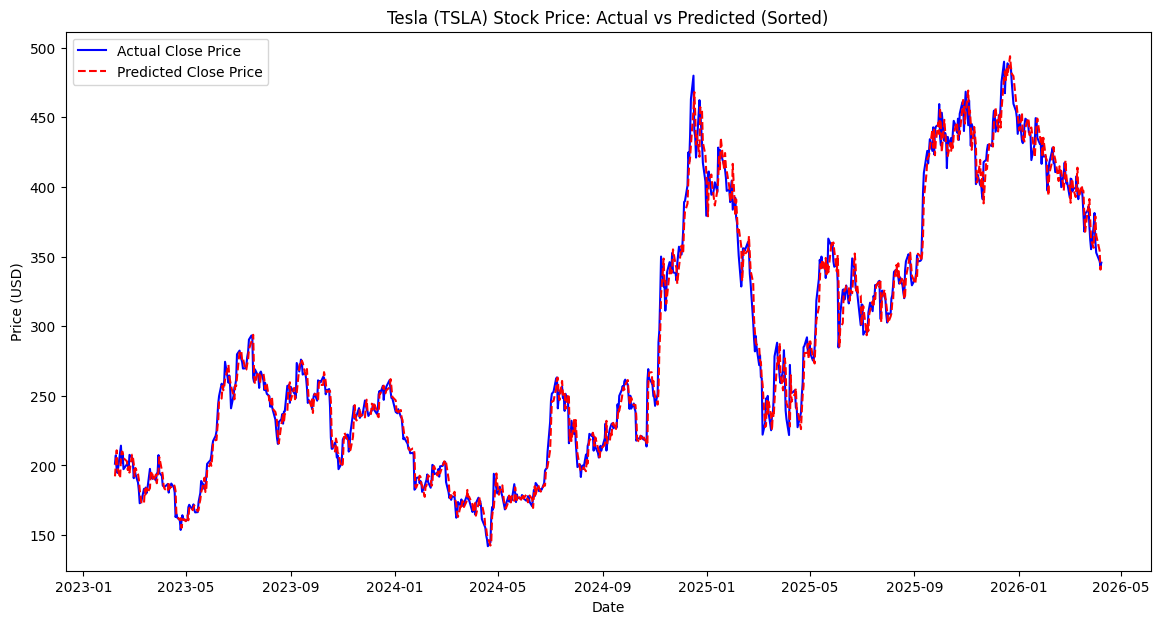

In [ ]:
## 7. Predict Next Day's Price (Latest Data)

print("\nFetching latest market data...")
latest_data = yf.download("TSLA", period="5d", progress=False)

if latest_data.empty:
    print("❌ Market data not available. Market may be closed.")
else:
    print(f"✓ Latest data retrieved (Last 5 days)")
    print(latest_data)
    
    # Get the most recent day's data
    most_recent = latest_data.iloc[-1:]
    
    # Prepare features for prediction
    current_features = most_recent[['Open', 'High', 'Low', 'Volume']]
    
    # Make predictions
    linear_next_pred = linear_model.predict(current_features)[0]
    random_next_pred = random_model.predict(current_features)[0]
    current_price = most_recent['Close'].values[0]
    
    print(f"\n" + "="*60)
    print("NEXT DAY PRICE PREDICTION")
    print("="*60)
    print(f"Current Price (Latest Close): ${current_price:.2f}")
    print(f"Date: {most_recent.index[0].date()}")
    print(f"\nPredictions:")
    print(f"  Linear Regression:  ${linear_next_pred:.2f}")
    print(f"  Random Forest:      ${random_next_pred:.2f}")
    print(f"  Ensemble Average:   ${(linear_next_pred + random_next_pred) / 2:.2f}")
    
    # Calculate expected changes
    linear_change = ((linear_next_pred - current_price) / current_price) * 100
    random_change = ((random_next_pred - current_price) / current_price) * 100
    
    print(f"\nExpected Change from Current Price:")
    print(f"  Linear Regression:  {linear_change:+.2f}%")
    print(f"  Random Forest:      {random_change:+.2f}%")
    print("="*60)

In [ ]:
## 8. Key Insights and Conclusions

print("\n" + "="*60)
print("KEY FINDINGS & INSIGHTS")
print("="*60)

print("\n1. MODEL PERFORMANCE:")
print(f"   • Random Forest outperforms Linear Regression")
print(f"   • RF R² Score: {random_r2:.4f} vs Linear R²: {linear_r2:.4f}")
print(f"   • RF RMSE: ${random_rmse:.2f} vs Linear RMSE: ${linear_rmse:.2f}")

print("\n2. FEATURE IMPORTANCE:")
for idx, row in feature_importance.iterrows():
    print(f"   • {row['Feature']}: {row['Importance']:.4f}")

print("\n3. TEMPORAL PATTERNS:")
print(f"   • Training Data: {len(X_train)} days ({X_train.index[0].date()} to {X_train.index[-1].date()})")
print(f"   • Test Data: {len(X_test)} days (most recent {(len(X_test)/len(X)*100):.1f}% of data)")
print(f"   • Recent data performance (last 20%): RF R² = {random_recent_r2:.4f}")

print("\n4. LIMITATIONS & CONSIDERATIONS:")
print("   • Stock prices are influenced by external factors (news, market sentiment)")
print("   • Historical price patterns may not repeat perfectly")
print("   • Short-term predictions are more challenging than long-term trends")
print("   • Model assumes market conditions remain relatively stable")

print("\n5. RECOMMENDATIONS:")
print("   • Use ensemble predictions (average of both models)")
print("   • Incorporate additional features (moving averages, momentum indicators)")
print("   • Retrain models periodically with new data")
print("   • Consider risk management strategies alongside predictions")

print("="*60)

[*********************100%***********************]  1 of 1 completed

Latest available prediction: $351.59


In [ ]:
# Summary statistics
print("\nDATASET AND TRAINING SUMMARY:")
print(f"• Total historical records: {len(data)}")
print(f"• Training samples: {len(X_train)}")
print(f"• Testing samples: {len(X_test)}")
print(f"• Features: {', '.join(features)}")
print(f"• Target variable: Next Day's Closing Price")
print(f"• Date range: {data.index[0].date()} to {data.index[-1].date()}")

Latest available prediction: $359.46
